In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('data/train.csv')
sns.set_theme(style="whitegrid")

## 1. Анализ целевой переменной

Распределение значений TARGET:
TARGET
0    73012
1     3008
Name: count, dtype: int64

Доли классов:
TARGET
0    0.960431
1    0.039569
Name: proportion, dtype: float64


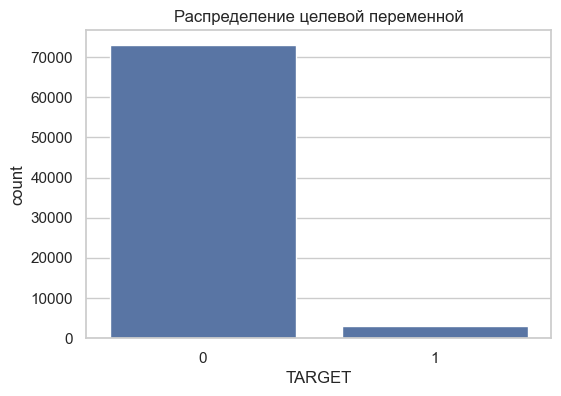

In [ ]:
# 1. Анализ целевой переменной
TARGET_NM = 'TARGET'

# Численный анализ
print(f"Распределение значений {TARGET_NM}:")
print(df[TARGET_NM].value_counts())
print(f"\nДоли классов:")
print(df[TARGET_NM].value_counts(normalize=True))

# Визуализация
plt.figure(figsize=(6, 4))
sns.countplot(x=TARGET_NM, data=df)
plt.title('Распределение целевой переменной')
plt.show()

# Если бы были временные метки, мы бы построили график зависимости среднего таргета от времени
# Но в данном датасете только численные признаки

## 2. Анализ признаков

Присутствуют только численные фичи без пропусков

In [5]:
# Типизация и пропуски
print("Информация о данных:")
print(df.info())

# Пропусках в признаках нет
print("\nПропущенные значения:", df.isnull().sum().sum())

Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76020 entries, 0 to 76019
Columns: 371 entries, ID to TARGET
dtypes: float64(111), int64(260)
memory usage: 215.2 MB
None

Пропущенные значения: 0


In [7]:
# Определение важности признаков и выбор топ-10 признаков
# Вычисляем корреляцию всех признаков с таргетом
target_corr = df.corrwith(df[TARGET_NM])
target_corr_abs = target_corr.abs().sort_values(ascending=False)

# Выбираем топ-10 признаков (исключая сам таргет, который идет первым)
top_features = target_corr_abs.index[1:11].tolist()

print("Топ-10 признаков по корреляции с таргетом:")
print(target_corr[top_features])

# Сохраним список для дальнейшей визуализации
features_to_plot = top_features

c:\Users\DELL\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\DELL\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Топ-10 признаков по корреляции с таргетом:
ind_var30             -0.149811
num_meses_var5_ult3   -0.148253
num_var30             -0.138289
num_var42             -0.135693
ind_var5              -0.135349
num_var5              -0.134095
var36                  0.102919
var15                  0.101322
num_var4              -0.080194
num_var35             -0.076872
dtype: float64


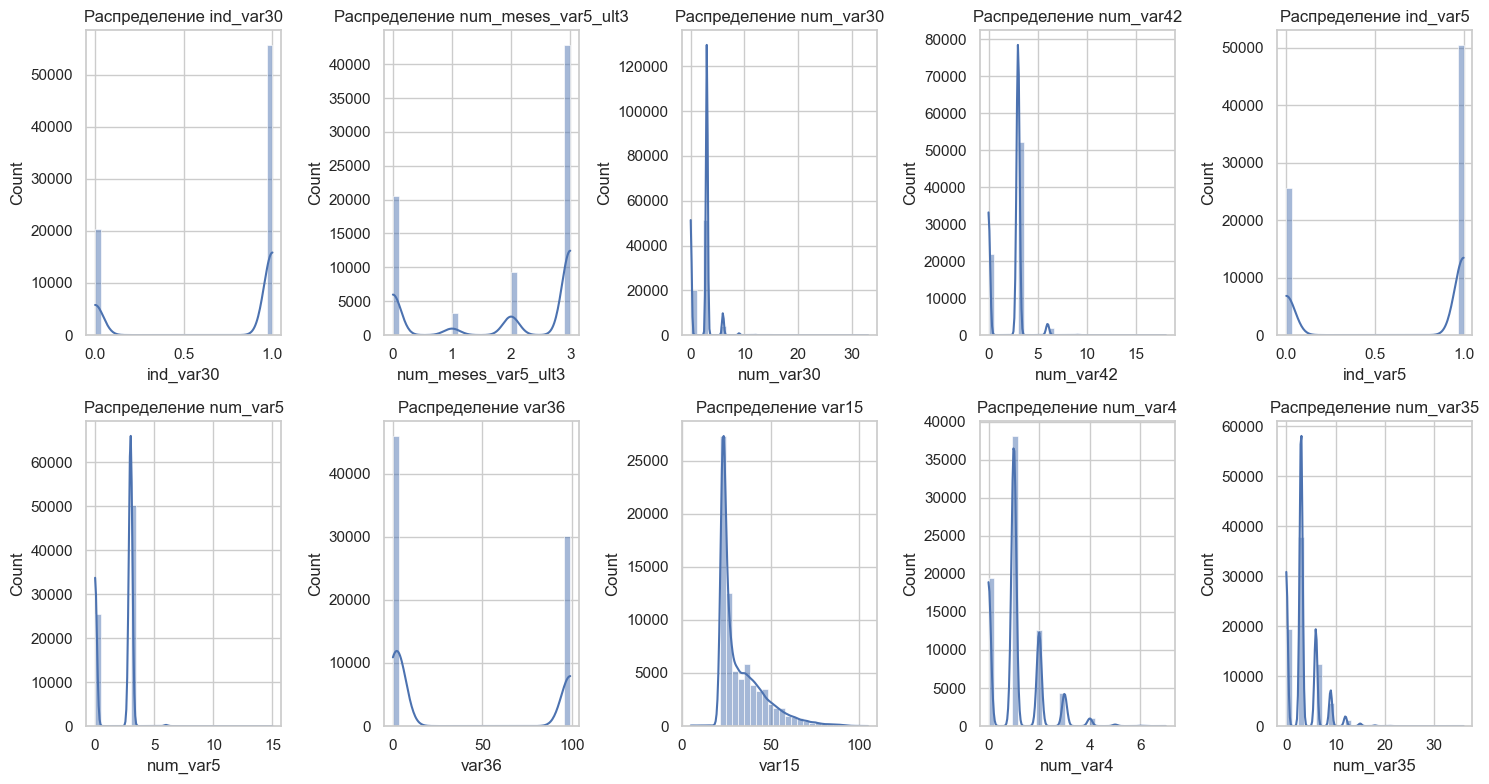

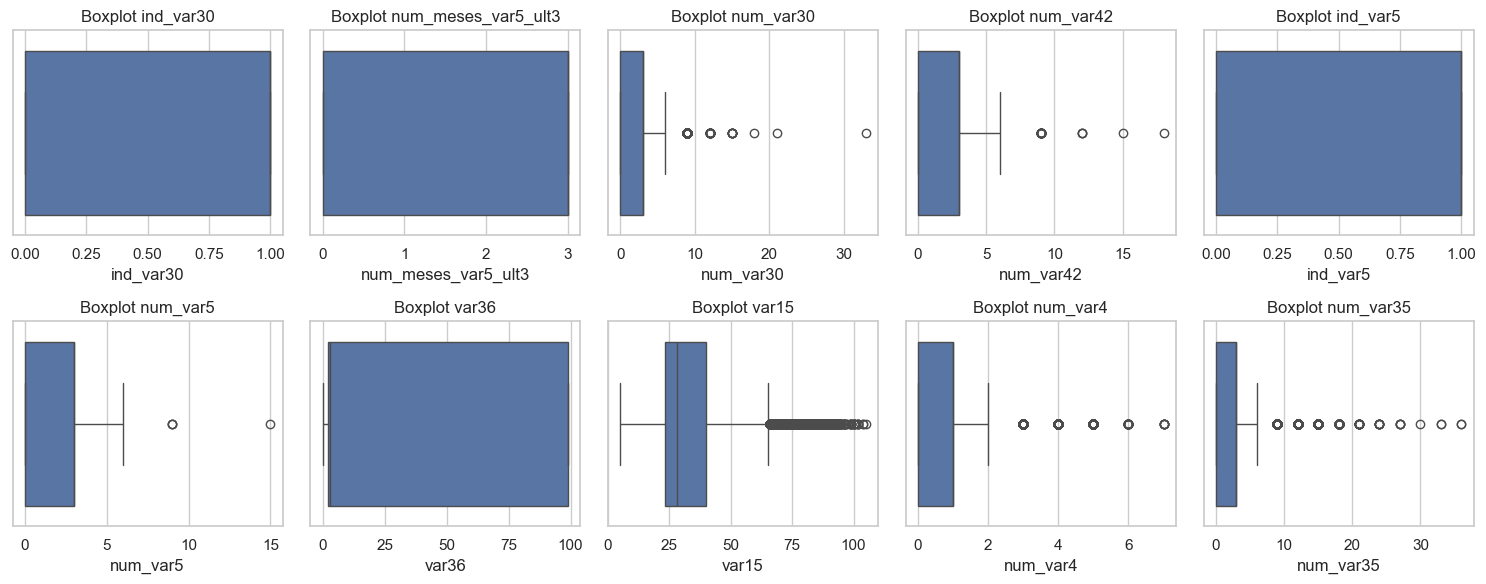

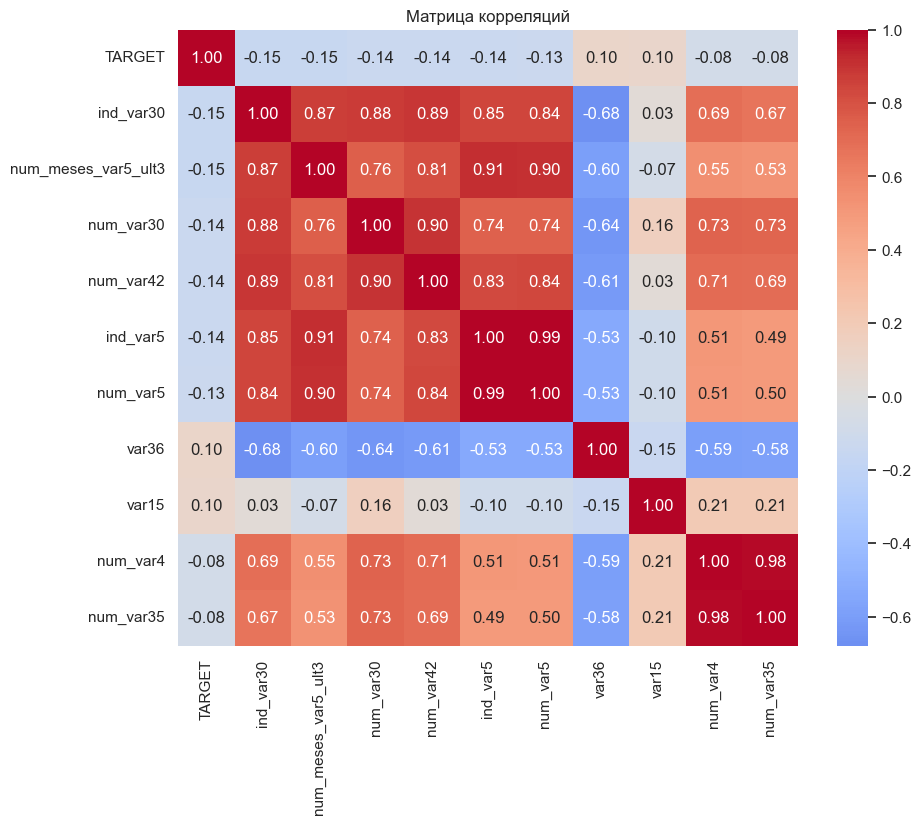

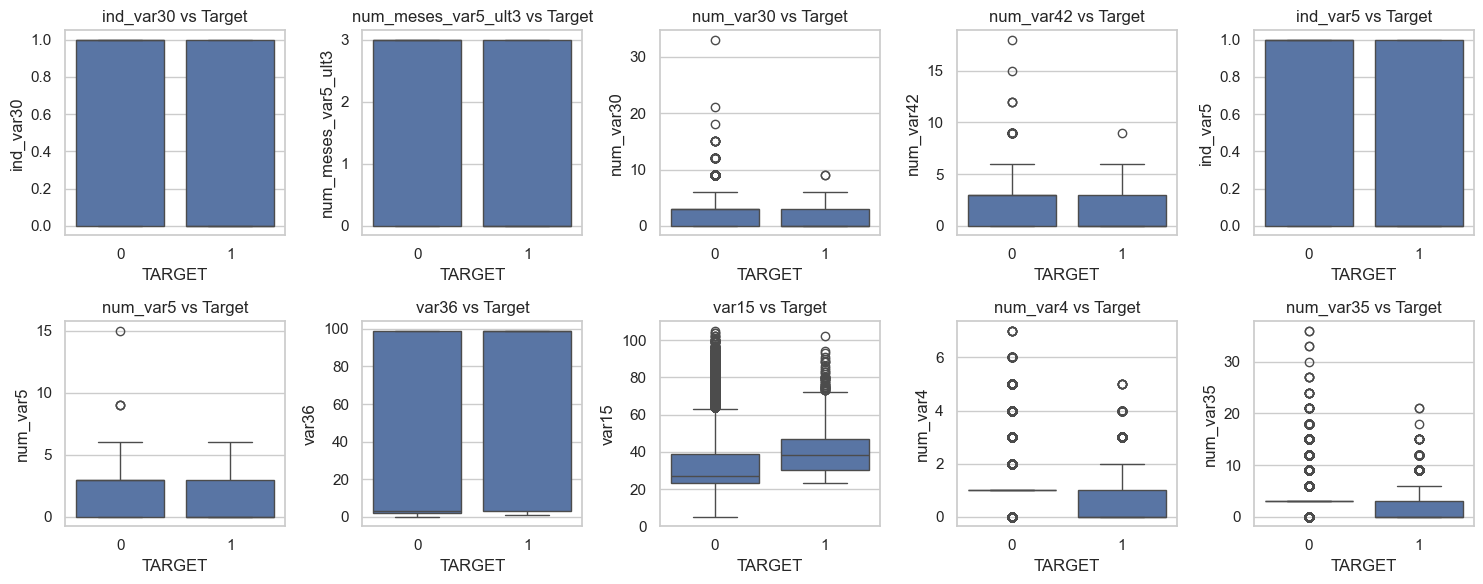

In [11]:
# Визуализация для топ 10 признаков

# 1. Распределения
plt.figure(figsize=(15, 8))
for i, col in enumerate(features_to_plot):
    plt.subplot(2, 5, i+1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Распределение {col}')
plt.tight_layout()
plt.show()

# 2. Boxplots (выбросы)
plt.figure(figsize=(15, 6))
for i, col in enumerate(features_to_plot):
    plt.subplot(2, 5, i+1)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot {col}')
plt.tight_layout()
plt.show()

# 3. Матрица корреляций
plt.figure(figsize=(10, 8))
cols_for_heatmap = [TARGET_NM] + features_to_plot
corr_matrix_top = df[cols_for_heatmap].corr()
sns.heatmap(corr_matrix_top, annot=True, cmap='coolwarm', center=0, fmt=".2f")
plt.title('Матрица корреляций')
plt.show()

# 4. Зависимость от таргета (Boxplots для каждого класса)
plt.figure(figsize=(15, 6))
for i, col in enumerate(features_to_plot):
    plt.subplot(2, 5, i+1)
    sns.boxplot(x=TARGET_NM, y=col, data=df)
    plt.title(f'{col} vs Target')
plt.tight_layout()
plt.show()

### Анализ возможных преобразований и генерации новых признаков

Градиентный бустинг, который я буду обучать против LAMA, хорошо работает и без преобразований над признаками. Если у меня не получится победить LAMA на оригинальных признаках, я дополню этот раздел позже